# Inspect SC transcriptomics datasets (unified `.h5ad`)

Each dataset is one `expression.h5ad`: sparse `X` (uint8 raw UMI counts), per-cell
metadata in `obs`, feature accessions in `var_names`, and `uns` = {modality,
value_semantics}. Set `DATASET` below to switch between **`protein_mapped`** (genes summed into UniProt proteins) and **`all_transcripts`** (native Ensembl genes).

The matrix is ~16 GB, so we never load it whole: metadata comes from `obs`, and matrix stats use a fast spread-sample of contiguous cell windows.

In [1]:
import numpy as np
import pandas as pd
import h5py
import anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt
from pathlib import Path

# Which dataset to inspect: "protein_mapped" or "all_transcripts"
DATASET = "all_transcripts"

_here = Path.cwd()
H5AD = next(p for p in [
    _here / "transcriptomics" / "output" / DATASET / "expression.h5ad",
    _here / "output" / DATASET / "expression.h5ad",
    _here.parent / "output" / DATASET / "expression.h5ad",
] if p.exists())
print("Inspecting:", H5AD)

Inspecting: C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\protgpt\transcriptomics\output\all_transcripts\expression.h5ad


In [2]:
# Load obs/var/uns only — X stays on disk (backed), so no 16 GB load.
adata = ad.read_h5ad(H5AD, backed="r")
meta = adata.obs.copy()
# drop unused categorical levels (Census ships its full tissue/cell-type vocab;
# we fetched only a subset, so empty categories like 'adrenal gland' linger otherwise)
for _c in meta.select_dtypes('category').columns:
    meta[_c] = meta[_c].cat.remove_unused_categories()
features = adata.var_names.to_list()
n_cells, n_feat = adata.shape
modality = adata.uns.get("modality"); semantics = adata.uns.get("value_semantics")
adata.file.close()

print(f"cells x features : {n_cells:,} x {n_feat:,}")
print(f"modality         : {modality}   value_semantics: {semantics}")
print(f"feature ids      : {features[:3]} ...")
print(f"obs columns      : {list(meta.columns)}")
meta.head()

cells x features : 4,550,106 x 61,497
modality         : transcriptomics   value_semantics: umi_counts
feature ids      : ['ENSG00000237491', 'ENSG00000188976', 'ENSG00000187642'] ...
obs columns      : ['dataset_id', 'cell_type', 'tissue', 'tissue_general', 'disease', 'donor_id', 'sex', 'assay', 'development_stage', 'self_reported_ethnicity', 'raw_sum', 'nnz', 'is_primary_data', 'suspension_type']


,dataset_id,cell_type,tissue,tissue_general,disease,donor_id,sex,assay,development_stage,self_reported_ethnicity,raw_sum,nnz,is_primary_data,suspension_type
cell_id,,,,,,,,,,,,,,
cell_0,8b2e5453-faf7-46ea-9073-aea69b283cb7,basal cell of prostate epithelium,transition zone of prostate,prostate gland,benign prostatic hyperplasia,BPH342,male,10x 3' v2,57-year-old stage,European American,10368.0,2528,True,cell
cell_1,8b2e5453-faf7-46ea-9073-aea69b283cb7,prostate gland microvascular endothelial cell,transition zone of prostate,prostate gland,benign prostatic hyperplasia,BPH342,male,10x 3' v2,57-year-old stage,European American,6105.0,1848,True,cell
cell_2,8b2e5453-faf7-46ea-9073-aea69b283cb7,basal cell of prostate epithelium,transition zone of prostate,prostate gland,benign prostatic hyperplasia,BPH342,male,10x 3' v2,57-year-old stage,European American,6150.0,1308,True,cell
cell_3,8b2e5453-faf7-46ea-9073-aea69b283cb7,luminal cell of prostate epithelium,transition zone of prostate,prostate gland,benign prostatic hyperplasia,BPH342,male,10x 3' v2,57-year-old stage,European American,6495.0,2064,True,cell
cell_4,8b2e5453-faf7-46ea-9073-aea69b283cb7,secretory cell,transition zone of prostate,prostate gland,benign prostatic hyperplasia,BPH342,male,10x 3' v2,57-year-old stage,European American,9510.0,2129,True,cell


In [3]:
# Random access into a gzip CSR is slow, so sample many small CONTIGUOUS windows
# spread across the file: fast, and spans all tissues (cells are grouped by tissue).
def sample_rows(n_windows=200, win=500, seed=0):
    with h5py.File(H5AD, "r") as f:
        Xg = f["X"]; indptr = Xg["indptr"][:]; N = len(indptr) - 1
        win = min(win, N // n_windows)
        starts = np.linspace(0, N - win, n_windows).astype(int)
        blocks, idxs = [], []
        for st in starts:
            s, e = int(indptr[st]), int(indptr[st + win])
            d = np.asarray(Xg["data"][s:e]); ii = np.asarray(Xg["indices"][s:e])
            ip = (indptr[st:st + win + 1] - indptr[st]).astype(np.int64)
            blocks.append(sp.csr_matrix((d, ii, ip), shape=(win, n_feat)))
            idxs.append(np.arange(st, st + win))
    return sp.vstack(blocks).tocsr(), np.concatenate(idxs)

Xs, samp_idx = sample_rows()                 # ~100k cells spread across the dataset
meta_s = meta.iloc[samp_idx].reset_index(drop=True)
print(f"working sample: {Xs.shape[0]:,} cells x {Xs.shape[1]:,} features, nnz={Xs.nnz:,}")

working sample: 100,000 cells x 61,497 features, nnz=207,066,923


## Value distribution & ties

Raw UMI counts are discrete and tie-dominated — this is what makes per-cell rank-binning fragile.

value range : 1-255, mean 3.88 (uint8)


value == 1  : 59.7%   == 2: 16.9%   == 3: 7.1%
distinct values / cell (median): 39
tied fraction  / cell (median): 0.991


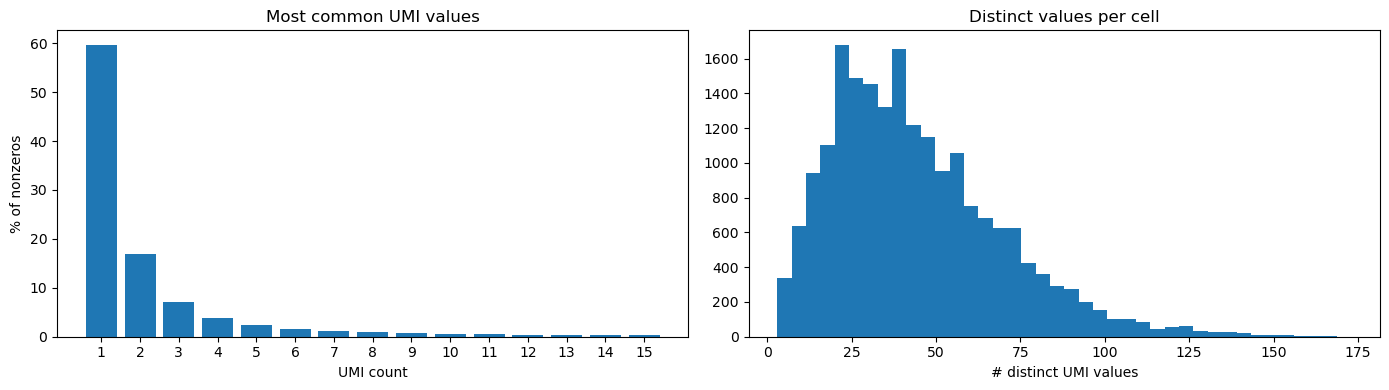

In [4]:
vals = Xs.data.astype(np.int64)
u, c = np.unique(vals, return_counts=True); order = np.argsort(-c)

# distinct values & tied fraction per cell (on up to 20k sampled cells)
ndist, tief = [], []
for r in range(min(Xs.shape[0], 20_000)):
    v = Xs.data[Xs.indptr[r]:Xs.indptr[r+1]]
    if len(v) < 5: continue
    uu, cc = np.unique(v, return_counts=True)
    ndist.append(len(uu)); tief.append(cc[cc > 1].sum() / len(v))

print(f"value range : {vals.min()}-{vals.max()}, mean {vals.mean():.2f} (uint8)")
print(f"value == 1  : {(vals==1).mean()*100:.1f}%   == 2: {(vals==2).mean()*100:.1f}%   == 3: {(vals==3).mean()*100:.1f}%")
print(f"distinct values / cell (median): {int(np.median(ndist))}")
print(f"tied fraction  / cell (median): {np.median(tief):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
top = order[:15]
ax[0].bar([str(int(u[i])) for i in top], c[top] / c.sum() * 100)
ax[0].set_title("Most common UMI values"); ax[0].set_xlabel("UMI count"); ax[0].set_ylabel("% of nonzeros")
ax[1].hist(ndist, bins=40); ax[1].set_title("Distinct values per cell"); ax[1].set_xlabel("# distinct UMI values")
plt.tight_layout(); plt.show()

## Metadata distributions

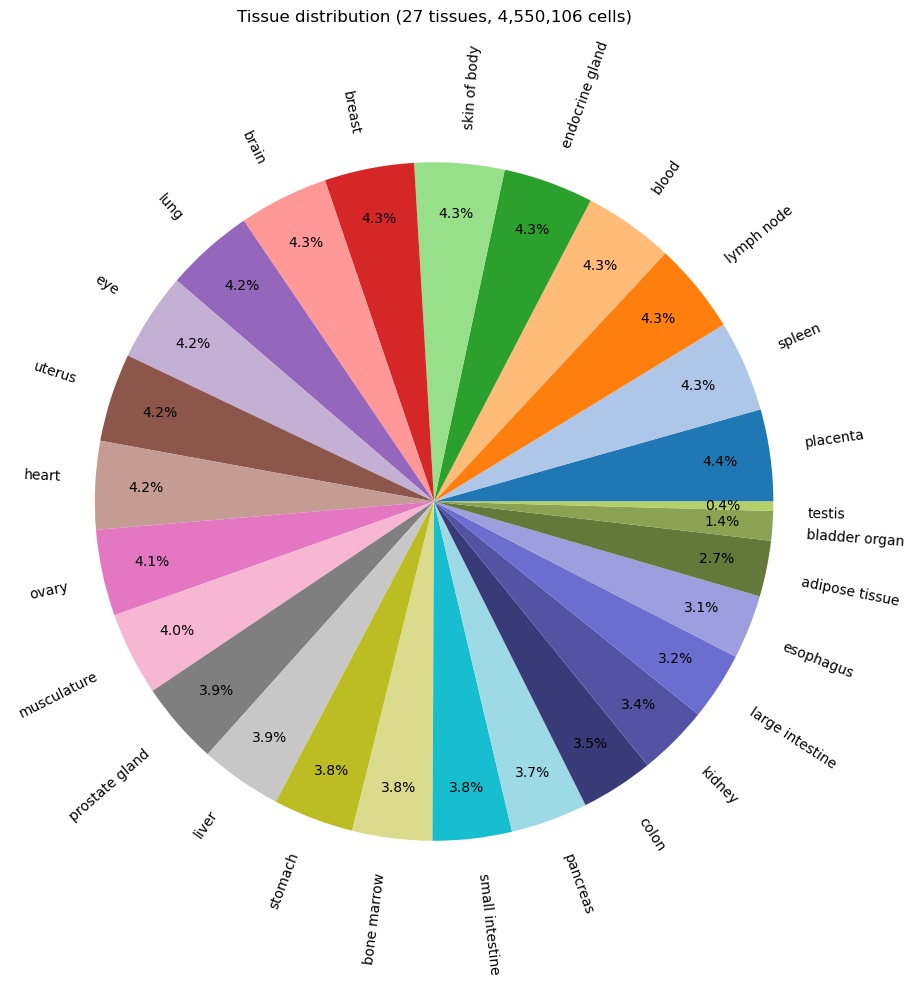

In [5]:
tc = meta["tissue_general"].value_counts(); tc = tc[tc > 0]
colors = plt.cm.tab20.colors + plt.cm.tab20b.colors
fig, ax = plt.subplots(figsize=(10, 10))
ax.pie(tc.values, labels=tc.index, autopct="%1.1f%%", pctdistance=0.85,
       textprops={"fontsize": 10}, rotatelabels=True,
       colors=[colors[i % len(colors)] for i in range(len(tc))])
ax.set_title(f"Tissue distribution ({len(tc)} tissues, {meta.shape[0]:,} cells)", pad=40)
plt.tight_layout(); plt.show()

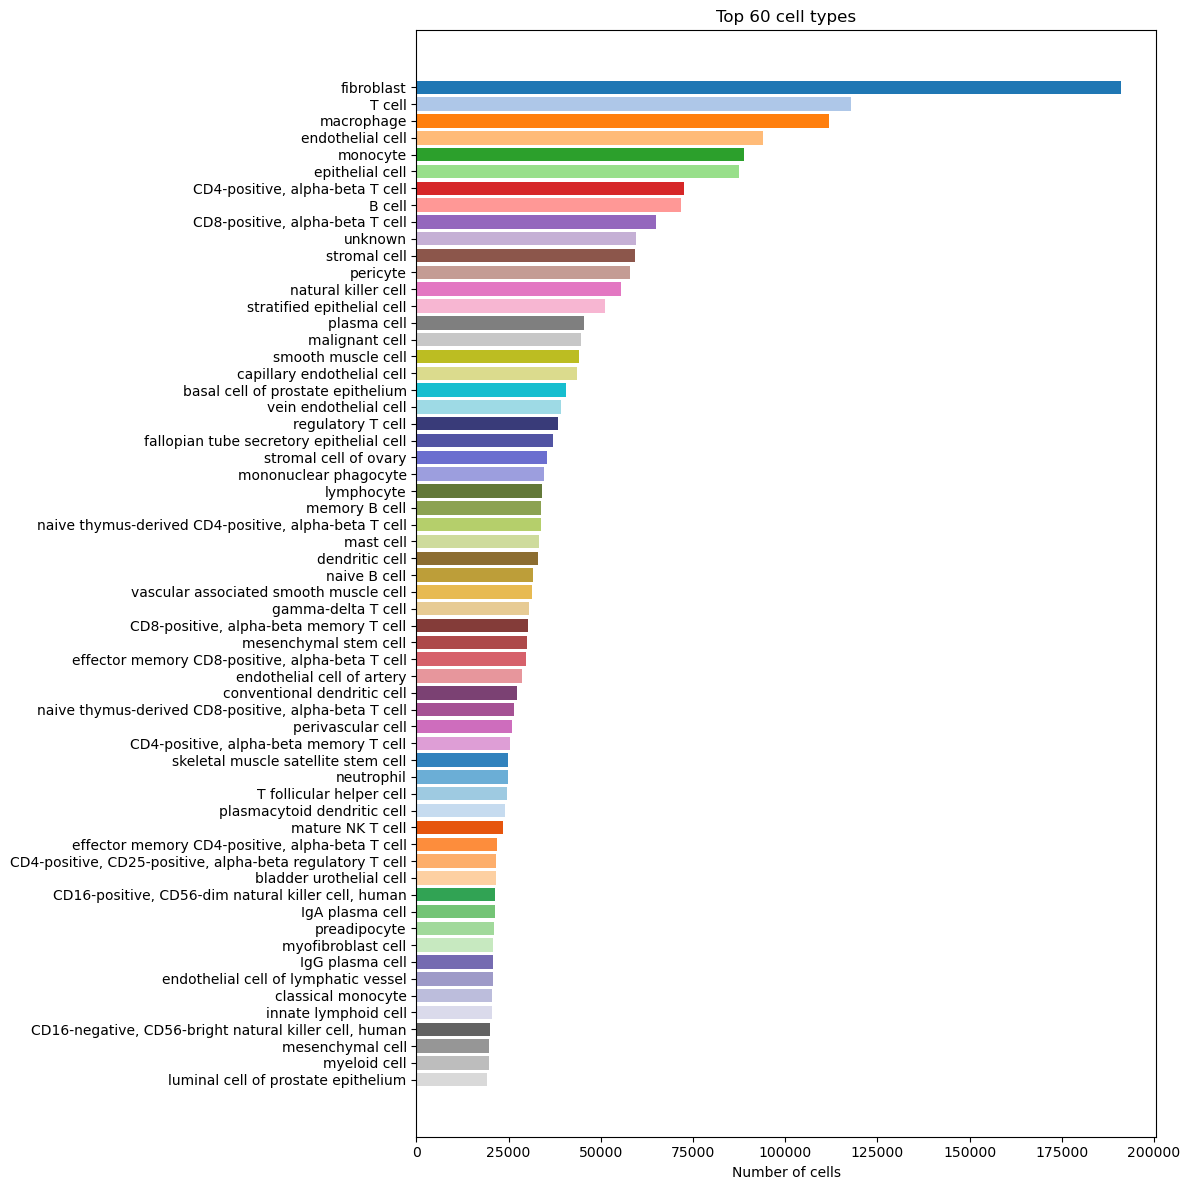

total cell types: 722


In [6]:
ct = meta["cell_type"].value_counts(); ct = ct[ct > 0].head(60)
colors = plt.cm.tab20.colors + plt.cm.tab20b.colors + plt.cm.tab20c.colors
fig, ax = plt.subplots(figsize=(12, 12))
ax.barh(ct.index[::-1], ct.values[::-1], color=[colors[i % len(colors)] for i in range(len(ct))][::-1])
ax.set_title(f"Top {len(ct)} cell types"); ax.set_xlabel("Number of cells")
plt.tight_layout(); plt.show()
print("total cell types:", meta["cell_type"].nunique())

## Per-cell QC metrics

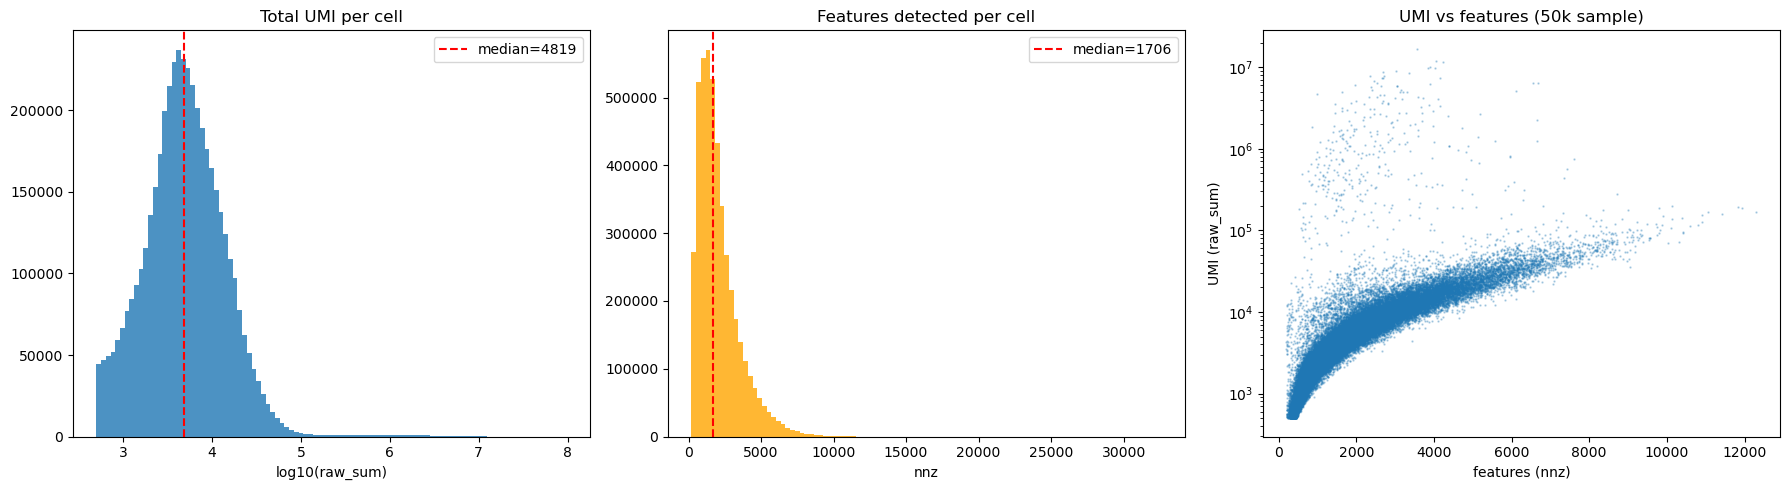

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(np.log10(meta["raw_sum"]), bins=100, alpha=0.8)
axes[0].axvline(np.log10(meta["raw_sum"].median()), color="red", ls="--", label=f'median={meta["raw_sum"].median():.0f}')
axes[0].set_title("Total UMI per cell"); axes[0].set_xlabel("log10(raw_sum)"); axes[0].legend()
axes[1].hist(meta["nnz"], bins=100, alpha=0.8, color="orange")
axes[1].axvline(meta["nnz"].median(), color="red", ls="--", label=f'median={meta["nnz"].median():.0f}')
axes[1].set_title("Features detected per cell"); axes[1].set_xlabel("nnz"); axes[1].legend()
idx = np.random.default_rng(0).choice(len(meta), size=min(50_000, len(meta)), replace=False)
axes[2].scatter(meta["nnz"].iloc[idx], meta["raw_sum"].iloc[idx], s=0.5, alpha=0.3)
axes[2].set_xlabel("features (nnz)"); axes[2].set_ylabel("UMI (raw_sum)"); axes[2].set_yscale("log")
axes[2].set_title("UMI vs features (50k sample)")
plt.tight_layout(); plt.show()

## Expression matrix statistics

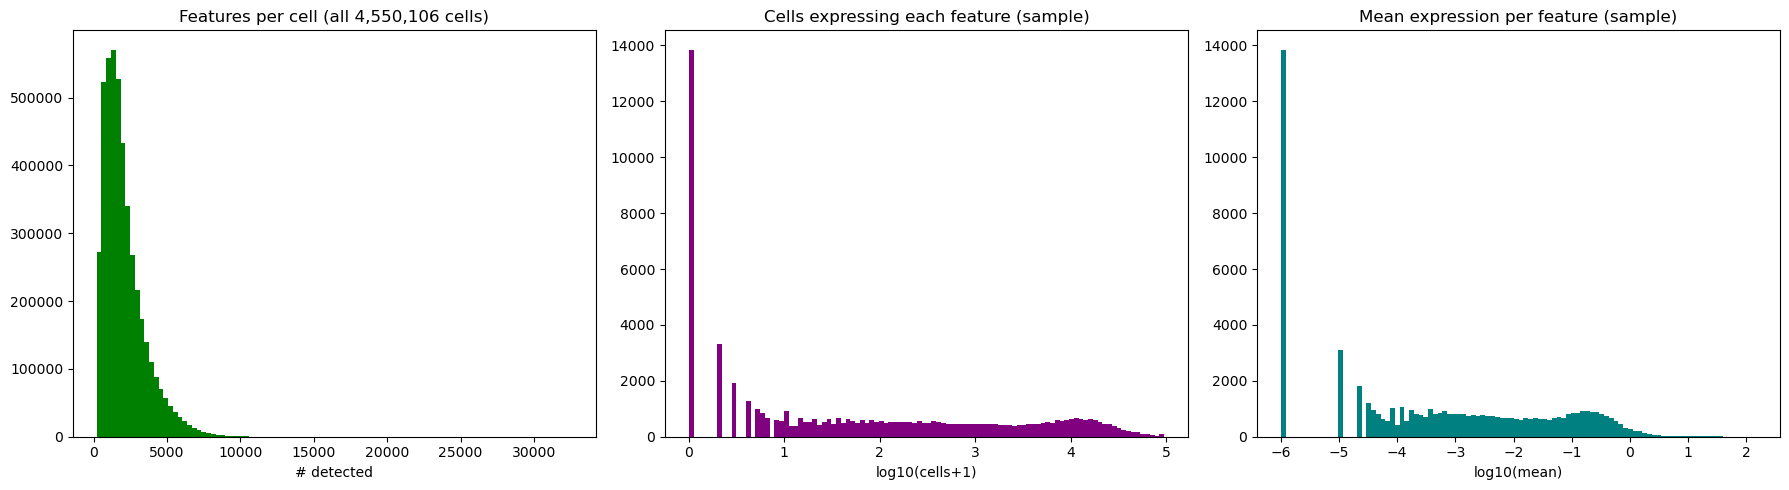

median features/cell : 1706
features in >50% of sampled cells: 471
features never seen in sample    : 13847 / 61497


In [8]:
# features per cell: cheap & exact (just the indptr); per-feature stats: on the sample
with h5py.File(H5AD, "r") as f:
    indptr_full = f["X"]["indptr"][:]
genes_per_cell = np.diff(indptr_full)
cells_per_feat = Xs.getnnz(axis=0)
mean_per_feat = np.asarray(Xs.sum(axis=0)).ravel() / Xs.shape[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(genes_per_cell, bins=100, color="green")
axes[0].set_title(f"Features per cell (all {n_cells:,} cells)"); axes[0].set_xlabel("# detected")
axes[1].hist(np.log10(cells_per_feat + 1), bins=100, color="purple")
axes[1].set_title("Cells expressing each feature (sample)"); axes[1].set_xlabel("log10(cells+1)")
axes[2].hist(np.log10(mean_per_feat + 1e-6), bins=100, color="teal")
axes[2].set_title("Mean expression per feature (sample)"); axes[2].set_xlabel("log10(mean)")
plt.tight_layout(); plt.show()
print(f"median features/cell : {int(np.median(genes_per_cell))}")
print(f"features in >50% of sampled cells: {(cells_per_feat > Xs.shape[0]*0.5).sum()}")
print(f"features never seen in sample    : {(cells_per_feat == 0).sum()} / {n_feat}")

## Per-tissue profiles

C:\Users\sander\AppData\Local\Temp\claude\ipykernel_28996\2198822992.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rs = meta.groupby("tissue_general")["raw_sum"].describe()[["25%","50%","75%"]].loc[tissues]
C:\Users\sander\AppData\Local\Temp\claude\ipykernel_28996\2198822992.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nz = meta.groupby("tissue_general")["nnz"].describe()[["25%","50%","75%"]].loc[tissues]


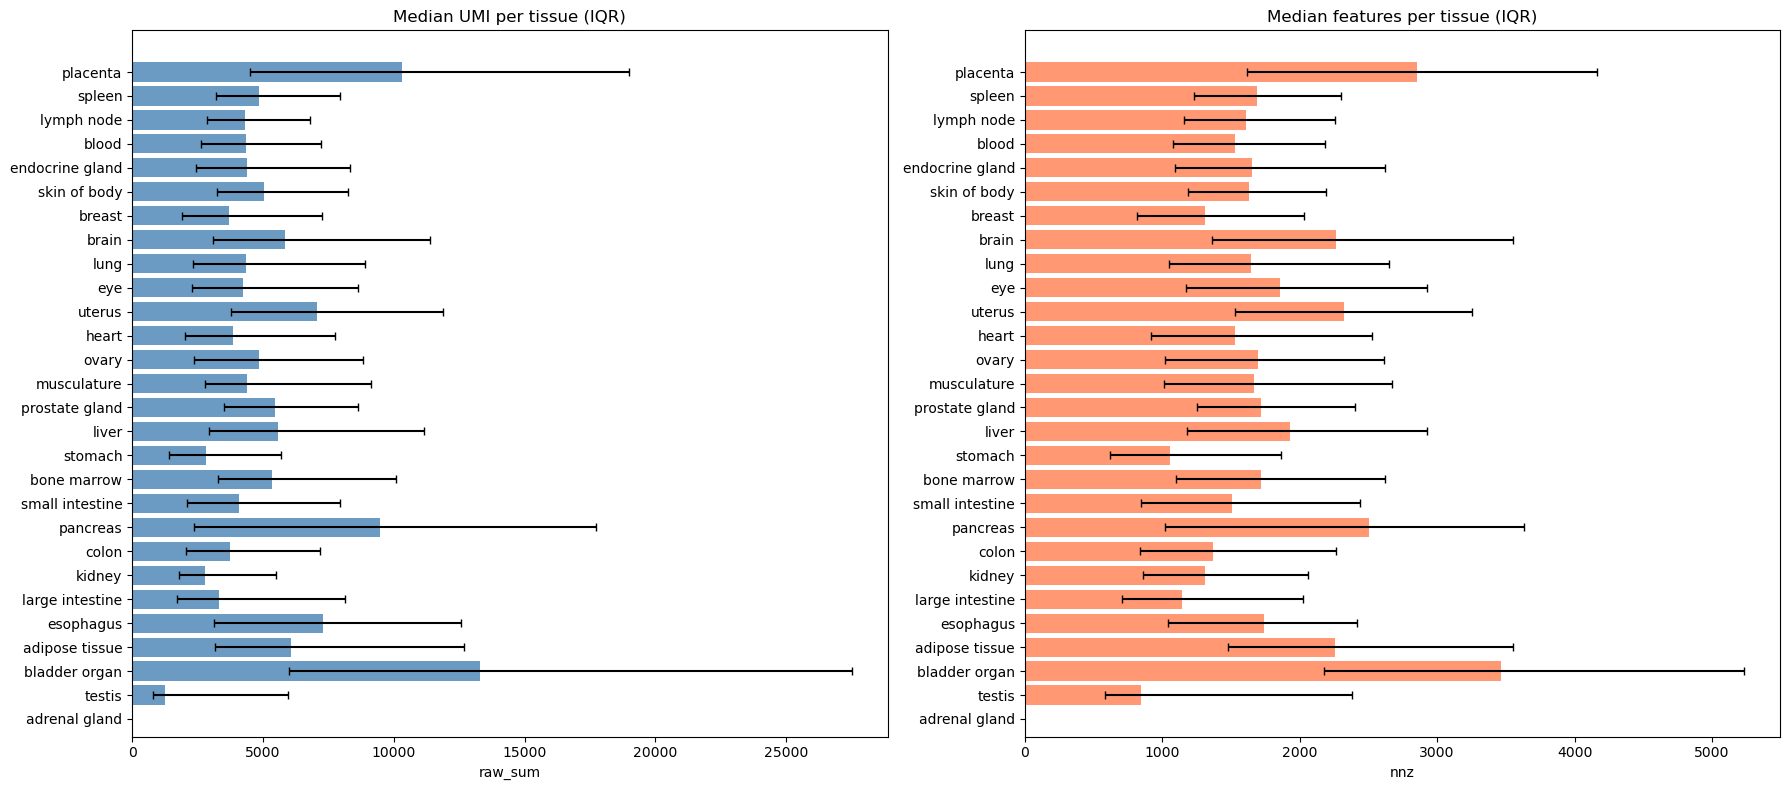

In [9]:
tissues = meta["tissue_general"].value_counts().index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
rs = meta.groupby("tissue_general")["raw_sum"].describe()[["25%","50%","75%"]].loc[tissues]
axes[0].barh(rs.index[::-1], rs["50%"].values[::-1],
             xerr=[rs["50%"].values[::-1]-rs["25%"].values[::-1], rs["75%"].values[::-1]-rs["50%"].values[::-1]],
             capsize=3, color="steelblue", alpha=0.8)
axes[0].set_title("Median UMI per tissue (IQR)"); axes[0].set_xlabel("raw_sum")
nz = meta.groupby("tissue_general")["nnz"].describe()[["25%","50%","75%"]].loc[tissues]
axes[1].barh(nz.index[::-1], nz["50%"].values[::-1],
             xerr=[nz["50%"].values[::-1]-nz["25%"].values[::-1], nz["75%"].values[::-1]-nz["50%"].values[::-1]],
             capsize=3, color="coral", alpha=0.8)
axes[1].set_title("Median features per tissue (IQR)"); axes[1].set_xlabel("nnz")
plt.tight_layout(); plt.show()

## Dataset & donor diversity

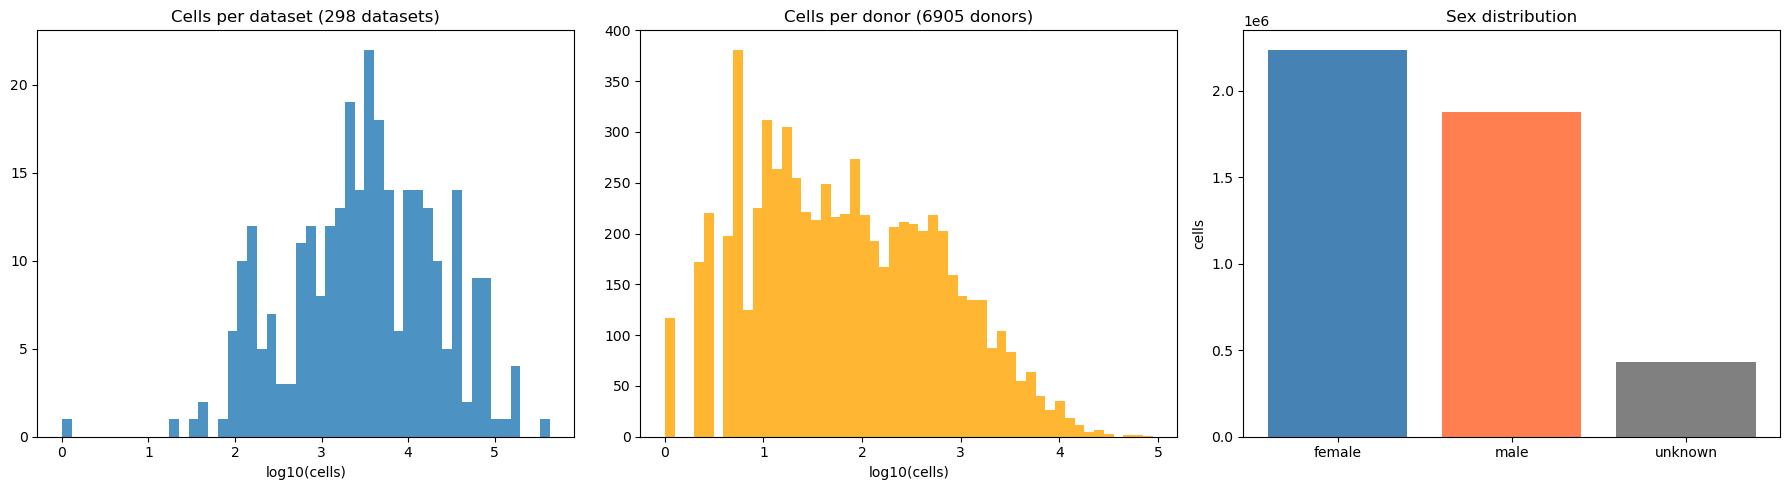

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ds = meta["dataset_id"].value_counts(); ds = ds[ds > 0]
axes[0].hist(np.log10(ds.values), bins=50, alpha=0.8)
axes[0].set_title(f"Cells per dataset ({meta['dataset_id'].nunique()} datasets)"); axes[0].set_xlabel("log10(cells)")
dn = meta["donor_id"].value_counts(); dn = dn[dn > 0]
axes[1].hist(np.log10(dn.values), bins=50, alpha=0.8, color="orange")
axes[1].set_title(f"Cells per donor ({meta['donor_id'].nunique()} donors)"); axes[1].set_xlabel("log10(cells)")
sx = meta["sex"].value_counts()
axes[2].bar(sx.index.astype(str), sx.values, color=["steelblue","coral","gray","green"][:len(sx)])
axes[2].set_title("Sex distribution"); axes[2].set_ylabel("cells")
plt.tight_layout(); plt.show()

## Dimensionality reduction (spread sample)

SVD → UMAP / t-SNE on a 10k-cell subsample of the spread sample, colored by tissue.

SVD var explained: 78.0%


C:\Users\sander\miniconda3\envs\prot_gpt\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


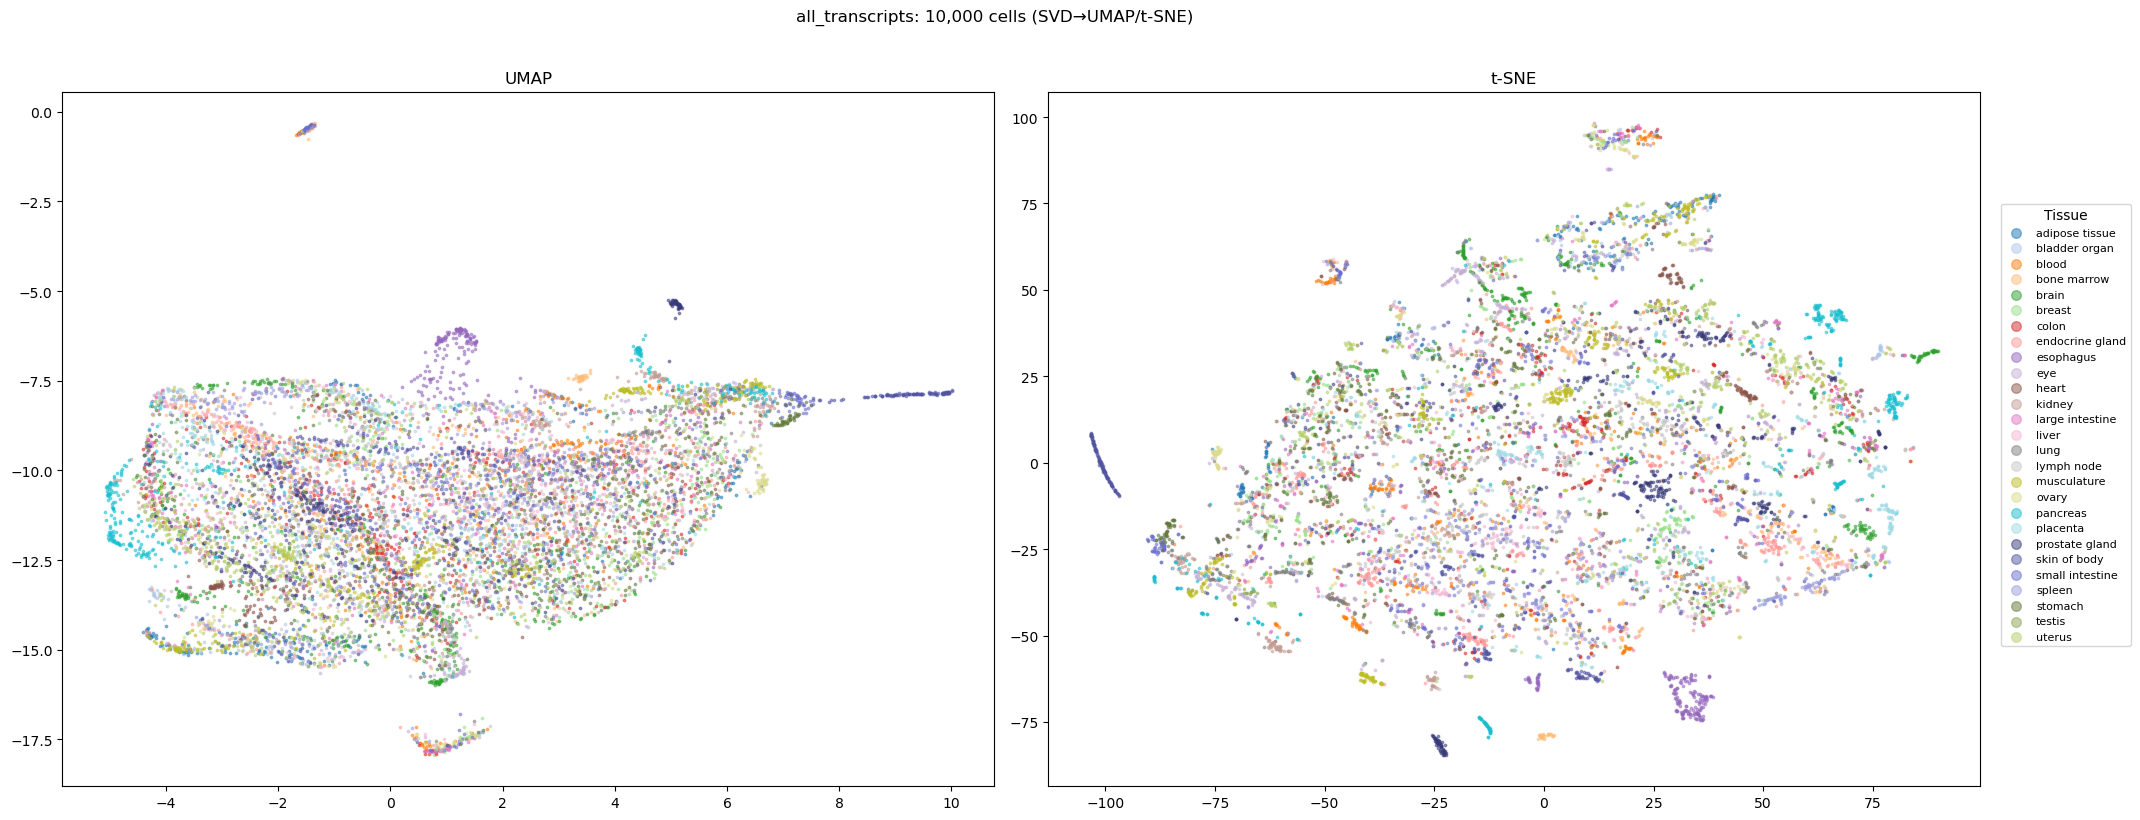

In [11]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from umap import UMAP

n_dr = min(10_000, Xs.shape[0])
sel = np.random.default_rng(0).choice(Xs.shape[0], n_dr, replace=False)
Xd = Xs[sel]; md_ = meta_s.iloc[sel].reset_index(drop=True)

svd = TruncatedSVD(n_components=50, random_state=0); Z = svd.fit_transform(Xd)
print(f"SVD var explained: {svd.explained_variance_ratio_.sum():.1%}")
umap_xy = UMAP(n_components=2, n_neighbors=30, min_dist=0.3, random_state=0).fit_transform(Z)
tsne_xy = TSNE(n_components=2, perplexity=30, random_state=0, max_iter=1000).fit_transform(Z)

tis = md_["tissue_general"].astype(str); uniq = sorted(tis.unique())
cols = list(plt.cm.tab20.colors)+list(plt.cm.tab20b.colors)+list(plt.cm.tab20c.colors)
cmap = {t: cols[i % len(cols)] for i, t in enumerate(uniq)}
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
for t in uniq:
    m = (tis == t).values
    ax[0].scatter(umap_xy[m,0], umap_xy[m,1], c=[cmap[t]], s=3, alpha=.5, label=t)
    ax[1].scatter(tsne_xy[m,0], tsne_xy[m,1], c=[cmap[t]], s=3, alpha=.5)
ax[0].set_title("UMAP"); ax[1].set_title("t-SNE")
fig.legend(*ax[0].get_legend_handles_labels(), loc="center left", bbox_to_anchor=(1, .5),
           markerscale=4, fontsize=8, title="Tissue")
fig.suptitle(f"{DATASET}: {n_dr:,} cells (SVD→UMAP/t-SNE)", y=1.02)
plt.tight_layout(); plt.show()